# 中文新闻文本分析与词云生成

本项目实现新闻文本的获取、清洗、中文分词、词频统计以及词云可视化分析。

主要流程：

网页数据获取 → 文本清洗 → 中文分词 → 关键词统计 → 可视化展示


In [14]:
# 导入依赖库
import requests
import re
import jieba
import pandas as pd

In [15]:
import matplotlib.pyplot as plt

In [16]:
from collections import Counter
import requests
import jieba
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from string import punctuation
import re

In [17]:
url="https://new.qq.com/rain/a/20230921A0A4Y900"
a = requests.get(url)
print(a.text)
wenzhang = a.text

<!DOCTYPE html>
<html lang="zh-CN">

<head>
    
<title>华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底_腾讯新闻</title>
<meta name="keywords" content="华为,华为Mate,智能手机市场,中国,mate,市场份额">
<meta name="description" content="近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4....">
<meta name="author" content="腾讯网">
<meta name="copyright" content="Copyright 1998 - 2026 Tencent. All Rights Reserved">
<meta property="og:type" content="news" />

<meta property="og:title" content="华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底_腾讯新闻" />
<meta property="og:description" content="近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4...." />
<meta property="og:url" content="https://news.qq.com/rain/a/20230921A0A4Y900" />
<meta property="og:image" content="https://inews.gtimg.com/om_ls/OHNnnJbBGBtU8uiG1GS4hmQ9ck2RW9mLO6f4LVl-dabO8AA_640330/0" />
<meta property="article:author" content="王小北Air" />
<meta property="article:published_time" 

In [18]:
t=wenzhang.split("<div class=\"content-article\">")[1]
t=t.split("<div id=\"Status\"></div>")[0]
print(t)


              <div id="article-column-tag"></div>
              <h1>华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底</h1>
              <div id="article-author"></div>
              <div id="article-content"></div>
            <div id="article-status"></div>
            <div id="article-promotion"></div>
            <div id="relate-question"></div>
            <div class="recommend-con" id="ArticleBottom"></div>
          </div>
        </div>
        <div id="recommend"></div>
        <div id="article-comment"></div>
        <div id="article-footer"></div>
      </div>
      <div id="content-right" class="content-right"></div>
    </div>
  </div>
  <div id="go-top"></div>
  <script>
    var navDom = document.getElementById('top-nav');
    if (window.isPcClient && navDom) {
      navDom.style.height = '0';
    }
  </script>
    <!-- v2文章加载深色模式脚本 -->
    <iframe style="display: none;" src="https://i.news.qq.com/web_backend/getWebPacUid"></iframe>
<script>
  try {
    if (!window.isPcClient) {
     

In [19]:
# 文本清洗函数

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = text.replace("\n", "")
    text = text.replace("\t", "")
    return text.strip()


cleaned_text = clean_text(t)

print(cleaned_text)


华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底                                                                                                                                                var navDom = document.getElementById('top-nav');    if (window.isPcClient && navDom) {      navDom.style.height = '0';    }            try {    if (!window.isPcClient) {      var iframe = document.createElement('iframe');      iframe.id = 'storageFrame';      iframe.style.display = 'none';      iframe.src = 'https://www.qq.com/storage-proxy';      document.body.appendChild(iframe);    }  } catch {}document.cookie="hel_err=;path=/;";


In [20]:
# 中文分词

stop_words = [
    "的",
    "了",
    "和",
    "是",
    "在"
]


def tokenize_text(text, stop_words):

    result = []

    for word in jieba.cut(text):

        word = word.strip()

        if word and word not in stop_words:
            result.append(word)

    return result


i = tokenize_text(cleaned_text, stop_words)

print(i)


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Cosmos\AppData\Local\Temp\jieba.cache
Loading model cost 1.071 seconds.
Prefix dict has been built successfully.


['华为', 'Mate60', '系列', '拿下', '中国', '智能手机', '市场', '第二', '，', '其中', 'Pro', '+', '销量', '或', '将', '垫底', 'var', 'navDom', '=', 'document', '.', 'getElementById', '(', "'", 'top', '-', 'nav', "'", ')', ';', 'if', '(', 'window', '.', 'isPcClient', '&&', 'navDom', ')', '{', 'navDom', '.', 'style', '.', 'height', '=', "'", '0', "'", ';', '}', 'try', '{', 'if', '(', '!', 'window', '.', 'isPcClient', ')', '{', 'var', 'iframe', '=', 'document', '.', 'createElement', '(', "'", 'iframe', "'", ')', ';', 'iframe', '.', 'id', '=', "'", 'storageFrame', "'", ';', 'iframe', '.', 'style', '.', 'display', '=', "'", 'none', "'", ';', 'iframe', '.', 'src', '=', "'", 'https', ':', '/', '/', 'www', '.', 'qq', '.', 'com', '/', 'storage', '-', 'proxy', "'", ';', 'document', '.', 'body', '.', 'appendChild', '(', 'iframe', ')', ';', '}', '}', 'catch', '{', '}', 'document', '.', 'cookie', '=', '"', 'hel', '_', 'err', '=', ';', 'path', '=', '/', ';', '"', ';']


In [21]:
# 文本基本统计

text_length = len(cleaned_text)
word_number = len(i)

print("文本字符数量:", text_length)
print("分词数量:", word_number)

print("前20个词:")
print(i[:20])


文本字符数量: 615
分词数量: 140
前20个词:
['华为', 'Mate60', '系列', '拿下', '中国', '智能手机', '市场', '第二', '，', '其中', 'Pro', '+', '销量', '或', '将', '垫底', 'var', 'navDom', '=', 'document']


In [22]:
# 词频统计

word_count = Counter(i)

top_words = word_count.most_common(20)

frequency_df = pd.DataFrame(
    top_words,
    columns=["关键词", "出现次数"]
)

frequency_df


,关键词,出现次数
0,.,15
1,',12
2,;,10
3,=,9
4,iframe,6
5,(,5
6,),5
7,document,4
8,{,4
9,},4


D:\Download\anaconda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21326 (\N{CJK UNIFIED IDEOGRAPH-534E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Download\anaconda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


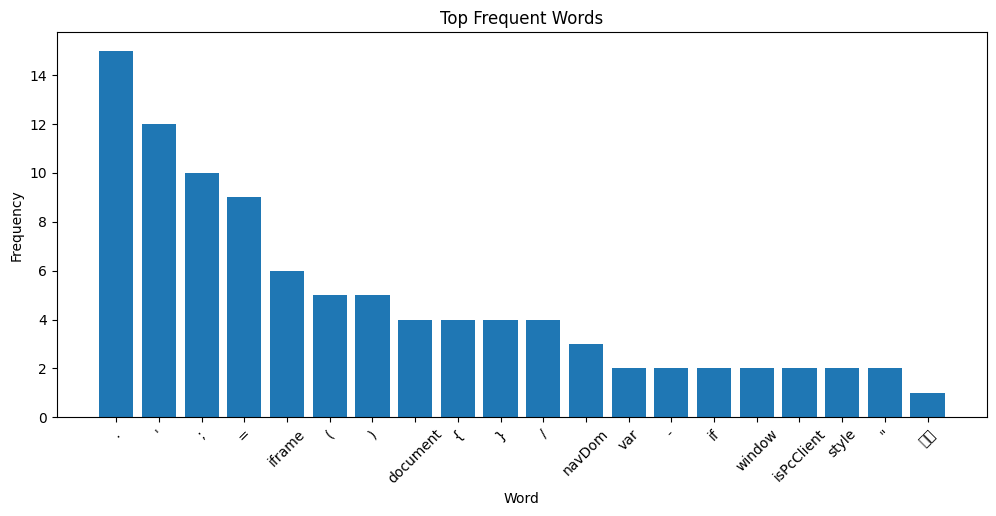

In [23]:
# 高频词柱状图

plt.figure(figsize=(12,5))

plt.bar(
    frequency_df["关键词"],
    frequency_df["出现次数"]
)

plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top Frequent Words")

plt.show()


In [24]:
# 保存分词结果

with open(
    "segmented_words.txt",
    "w",
    encoding="utf-8"
) as f:

    for word in i:
        f.write(word + "\n")

print("结果已保存")


结果已保存


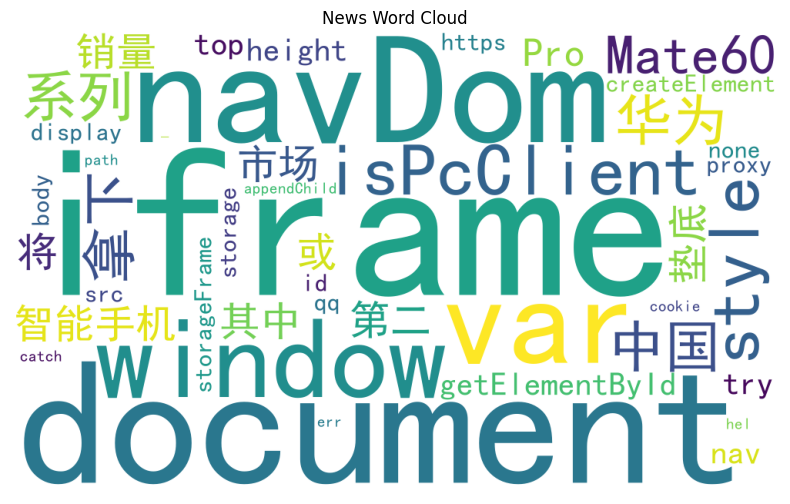

In [25]:
# 生成词云

wc = WordCloud(
    font_path="simhei.ttf",
    width=1000,
    height=600,
    background_color="white",
    max_words=300
)

wc.generate(
    " ".join(i)
)

plt.figure(figsize=(10,6))

plt.imshow(wc)

plt.axis("off")

plt.title("News Word Cloud")

plt.show()
